# Thermostat Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton for further how this is implemented please have a look at the bouncing ball source code in `hybrid_automatons` pkg.

![Thermostat Automaton Diagram](./figures/thermostat.png)

In [4]:
import os
from hybrid_automatons import thermostat
from hybrid_automaton import Automaton
from hybrid_automaton import RunResult
import numpy as np

In [5]:
ha: Automaton = thermostat(
    too_cold_threshold=18.0, 
    too_hot_threshold=22.0,
    ambient_temp=20.0,
    drift_rate=0.5
)
print (ha)

Hybrid Automaton Definition:
	name: Thermostat
	id: 1
	initial_mode: IDLE
	modes: [HEATING, COOLING, IDLE]
	transitions:
		HEATING --[heating_to_idle]--> IDLE
		COOLING --[cooling_to_idle]--> IDLE
		IDLE --[idle_to_heating]--> HEATING
		IDLE --[idle_to_cooling]--> COOLING
	guards:
		heating_to_idle: [temp_comfortable]
		cooling_to_idle: [temp_comfortable]
		idle_to_heating: [too_cold]
		idle_to_cooling: [too_hot]
	resets:
		heating_to_idle: <none>
		cooling_to_idle: <none>
		idle_to_heating: <none>
		idle_to_cooling: <none>
	invariants:
		HEATING: [<none>]
		COOLING: [<none>]
		IDLE: [<none>]
	continous_dynamics:
		HEATING -> heating_dynamics
		COOLING -> cooling_dynamics
		IDLE -> idle_dynamics



In [6]:
print (f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}")

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> IDLE
    HEATING --> IDLE: heating_to_idle
    COOLING --> IDLE: cooling_to_idle
    IDLE --> HEATING: idle_to_heating
    IDLE --> COOLING: idle_to_cooling


In [8]:
results: RunResult = await ha.activate(
    initial_continuous_state=np.array([25.0]),
    enable_real_time_mode=False,
    enable_self_integration=True,
    timeout_sec=30.0,
    delta_time=0.01,
    continuous_state_sampler_enabled=True,
    continuous_state_sampler_rate=100,
    output_dir= os.path.join(os.getcwd(), 'logs/thermostat_run')
)
print (results)

❄️  COOLING - Turning AC ON
😌 IDLE - Systems off, maintaining temperature
Automaton Run Summary
Run ID: 20260203T125150Z_0721fd
Status: TIMEOUT
logs directory: /home/ryan/hybrid-automaton/notebooks/logs/thermostat_run

Termination:
  Code: CANCELLED
  Message: Timeout exceeded
  Final State: IDLE

Execution Metrics:
  Total Runtime: 3.585s
  Total Steps: 3003
  Transitions: 2

Step Statistics:
  TRANSITION: 2
  NORMAL: 3001


In [25]:
print (repr(ha))

stateDiagram-v2
    direction LR
    [*] --> IDLE
    HEATING --> IDLE: heating_to_idle
    COOLING --> IDLE: cooling_to_idle
    IDLE --> HEATING: idle_to_heating
    IDLE --> COOLING: idle_to_cooling


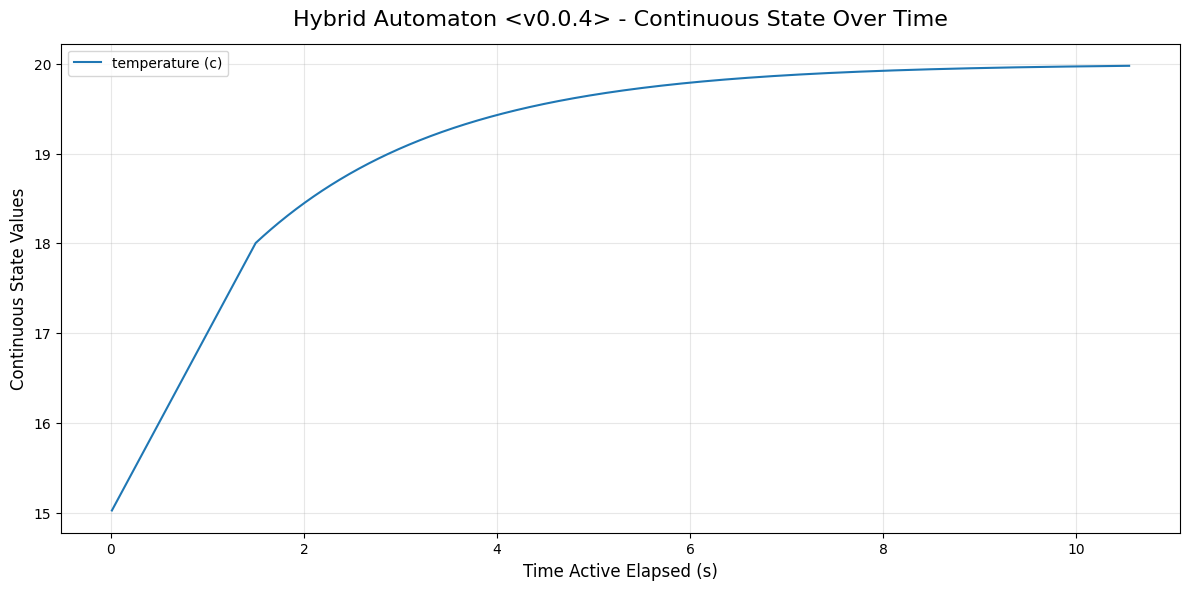

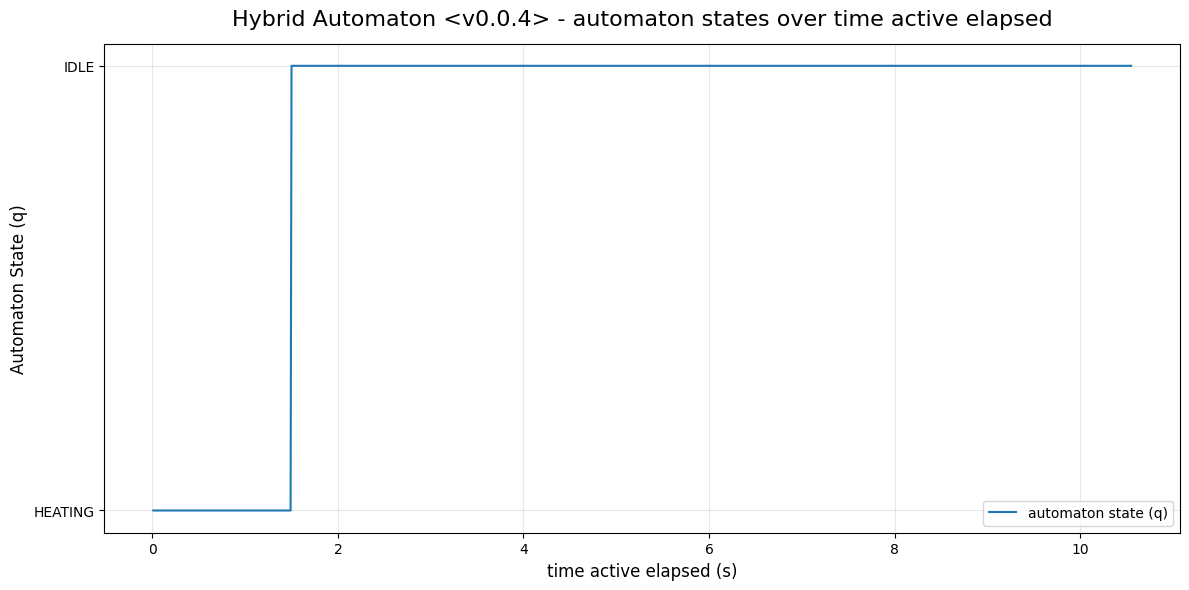

In [26]:
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, transitions_times_over_time_fig, automaton_states_over_time
import matplotlib.pyplot as plt

results = ha_runner.get_results()
fig1 = continuous_states_over_time_fig(results['continuous_states'], ['temperature (c)'])
# fig2 = transitions_times_over_time_fig(results['transition_times'])
fig3 = automaton_states_over_time(results['automaton_states'])

plt.show()

IndexError: tuple index out of range

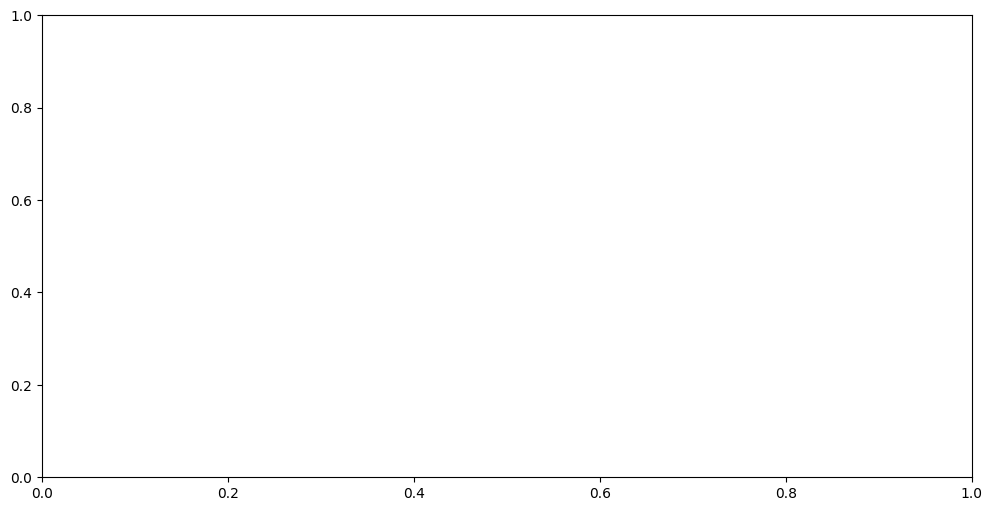

In [30]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
await ha_runner.run(x0 = np.array([30.0]), collect_continuous=True, collect_automaton=True, real_time_mode=False, duration=30.0, integrate=True, dt=0.01, collect_control=False, collect_auxiliary=False)

results = []
results = ha_runner.get_results()
fig1 = continuous_states_over_time_fig(results['continuous_states'], ['temperature (c)'])
# fig2 = transitions_times_over_time_fig(results['transition_times'])
fig3 = automaton_states_over_time(results['automaton_states'])

plt.show()